In [15]:
!pip install easyocr
!pip install imutils


In [16]:
from google.colab import files

uploaded = files.upload()


Saving car.jpg to car (1).jpg


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


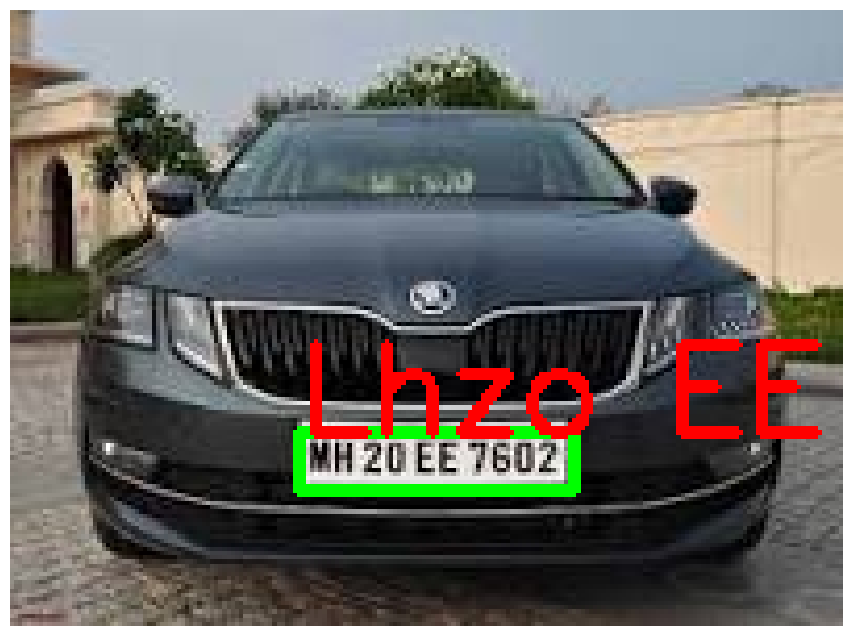

Detected Texts:
Lhzo EE 7602/


In [18]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('car.jpg')

# Convert BGR to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Initialize EasyOCR
reader = easyocr.Reader(['en'])

# Detect text
results = reader.readtext(rgb_image)

# Draw results
for result in results:

    # Get coordinates
    top_left = tuple(map(int, result[0][0]))
    bottom_right = tuple(map(int, result[0][2]))

    # Extract text
    text = result[1]

    # Draw rectangle
    cv2.rectangle(
        rgb_image,
        top_left,
        bottom_right,
        (0,255,0),
        2
    )

    # Put text
    cv2.putText(
        rgb_image,
        text,
        top_left,
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255,0,0),
        2
    )

# Show image
plt.figure(figsize=(12,8))

plt.imshow(rgb_image)

plt.axis('off')

plt.show()

# Print detected text
print("Detected Texts:")

for result in results:
    print(result[1])